In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
pio.renderers.default='colab'
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob

files = glob.glob("/content/drive/MyDrive/Basketball_analysis/*.csv")

df = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)


df.to_csv(
    "/content/drive/MyDrive/Basketball_analysis/season_stats.csv",
    index=False
)
df.shape


(25087, 65)

In [ ]:
import glob

files = glob.glob("/content/drive/MyDrive/team_stats/*.csv")

team_df = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)


team_df.to_csv(
    "/content/drive/MyDrive/Basketball_analysis/team_stats.csv",
    index=False
)
team_df.shape

(1794, 19)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Basketball_analysis/season_stats.csv')

In [ ]:
team_df = pd.read_csv('/content/drive/MyDrive/Basketball_analysis/team_stats.csv')

In [ ]:
combined_df = df.merge(
    team_df,
    on=["team", "year","conf"],
    how="left"
)



In [ ]:
combined_df.head(4)

,player,pos,exp,num,hgt,team,conf,g,min,mpg,...,adj_t,adj_t_rk,wab,nc_elite_sos,nc_fut_sos,nc_cur_sos,ov_elite_sos,ov_fut_sos,ov_cur_sos,seed
0,Jalen Coleman-Lands,Wing G,Sr,55.0,6-4,Kansas,B12,39,19.8,8.2051,...,69.1149,71.0,10.409633,20.0,0.6267,0.6267,37.0,0.7798,0.7798,1.0
1,K.J. Walton,Wing G,Sr,1.0,6-3,Akron,MAC,4,5.9,19.5000,...,61.9483,352.0,-4.269942,10.0,0.3309,0.3309,11.0,0.3827,0.3827,13.0
2,Camron Justice,Combo G,Sr,5.0,6-3,Western Kentucky,CUSA,28,76.5,32.0000,...,68.7010,94.0,-6.346622,17.0,0.4280,0.4280,14.0,0.4620,0.4620,NaN
3,Traci Carter,Scoring PG,Sr,25.0,6-1,Hartford,AE,22,51.2,29.9091,...,67.1470,178.0,-15.987583,9.0,0.3635,0.3635,8.0,0.3253,0.3253,NaN


In [ ]:
team_counts = (
    df.groupby("id")["team"]
      .nunique()
      .reset_index(name="num_teams")
)
print(team_counts)

            id  num_teams
0        37479          1
1        39014          1
2        39412          1
3        39780          1
4        40204          2
...        ...        ...
11525   133656          1
11526   133659          1
11527   133660          1
11528   133661          1
11529  2450496          1

[11530 rows x 2 columns]


In [ ]:
combined_df = combined_df[(combined_df['g'] >= 5)]

In [ ]:
combined_df = combined_df.drop(columns=["num","g","ppg","oreb","dreb","rpg","apg","tov","spg","bpg",
                  "efg","id","fgm","ftm","fta","two_a","two_m","three_m","three_a",
                  "dunk_m","dunk_a","dunk_pct","rim_m","rim_a","mid_m","mid_a","pick","fga",
                  "barthag_rk","adj_o_rk","adj_d_rk","adj_t_rk","seed","rec"], axis=1)


In [ ]:
combined_df.columns

Index(['player', 'pos', 'exp', 'hgt', 'team', 'conf', 'min', 'mpg', 'ast_to',
       'usg', 'ortg', 'ts', 'year', 'ft_pct', 'two_pct', 'three_pct',
       'rim_pct', 'mid_pct', 'porpag', 'dporpag', 'adj_oe', 'drtg', 'adj_de',
       'stops', 'obpm', 'dbpm', 'bpm', 'oreb_rate', 'dreb_rate', 'ast', 'to',
       'blk', 'stl', 'ftr', 'pfr', 'fg_pct', 'barthag', 'adj_o', 'adj_d',
       'adj_t', 'wab', 'nc_elite_sos', 'nc_fut_sos', 'nc_cur_sos',
       'ov_elite_sos', 'ov_fut_sos', 'ov_cur_sos'],
      dtype='object')

In [ ]:
print(combined_df.isnull().sum())

player             0
pos                3
exp                1
hgt               24
team               0
conf               0
min                0
mpg                1
ast_to           602
usg                0
ortg               0
ts                 0
year               0
ft_pct             0
two_pct            0
three_pct          0
rim_pct         1011
mid_pct         1391
porpag             0
dporpag            1
adj_oe             0
drtg               1
adj_de             1
stops              1
obpm               1
dbpm               1
bpm                1
oreb_rate          0
dreb_rate          0
ast                0
to                 0
blk                0
stl                0
ftr                0
pfr                0
fg_pct           159
barthag         4728
adj_o           4728
adj_d           4728
adj_t           4728
wab             4728
nc_elite_sos     253
nc_fut_sos       253
nc_cur_sos       253
ov_elite_sos     253
ov_fut_sos       253
ov_cur_sos       253
dtype: int64


In [ ]:
transfers = team_counts[team_counts["num_teams"] > 1]
transfers.shape


(3466, 2)

In [ ]:
combined_df = combined_df.sort_values(["player", "year"])

combined_df["previous_team"] = (
    combined_df.groupby("player")["team"]
      .shift(1)
)

combined_df["previous_conference"] = (
    combined_df.groupby("player")["conf"]
      .shift(1)
)


combined_df["is_transfer"] = (
    combined_df["previous_team"].notna() &
    (combined_df["team"] != combined_df["previous_team"])
)

combined_df.loc[~combined_df["is_transfer"], "previous_team"] = pd.NA
combined_df.loc[~combined_df["is_transfer"], "previous_conference"] = pd.NA

combined_df["previous_ortg"] = (
    combined_df.groupby("player")["ortg"]
      .shift(1)
)

combined_df["previous_drtg"] = (
    combined_df.groupby("player")["drtg"]
      .shift(1)
)

combined_df["previous_ts"] = (
    combined_df.groupby("player")["ts"]
      .shift(1)
)

combined_df["previous_usg"] = (
    combined_df.groupby("player")["usg"]
      .shift(1)
)

combined_df["previous_porpag"] = (
    combined_df.groupby("player")["porpag"]
      .shift(1)
)

combined_df["previous_adj_oe"] = (
    combined_df.groupby("player")["adj_oe"]
      .shift(1)
)

combined_df["previous_adj_de"] = (
    combined_df.groupby("player")["adj_de"]
      .shift(1)
)

combined_df["previous_bpm"] = (
    combined_df.groupby("player")["bpm"]
      .shift(1)
)

combined_df["previous_team_adjo"] = (
    combined_df.groupby("player")["adj_o"]
      .shift(1)
)

combined_df["previous_team_adjd"] = (
    combined_df.groupby("player")["adj_d"]
      .shift(1)
)

combined_df["previous_barthag"] = (
    combined_df.groupby("player")["barthag"]
      .shift(1)
)




In [ ]:
combined_df["change_ortg"] = combined_df["ortg"] - combined_df["previous_ortg"]
combined_df["change_drtg"] = combined_df["drtg"] - combined_df["previous_drtg"]
combined_df["change_ts"] = combined_df["ts"] - combined_df["previous_ts"]
combined_df["change_usg"] = combined_df["usg"] - combined_df["previous_usg"]
combined_df["change_porpag"] = combined_df["porpag"] - combined_df["previous_porpag"]
combined_df["change_adj_oe"] = combined_df["adj_oe"] - combined_df["previous_adj_oe"]
combined_df["change_adj_de"] = combined_df["adj_de"] - combined_df["previous_adj_de"]
combined_df["change_bpm"] = combined_df["bpm"] - combined_df["previous_bpm"]
combined_df["change_team_adjo"] = combined_df["adj_o"] - combined_df["previous_team_adjo"]
combined_df["change_team_adjd"] = combined_df["adj_d"] - combined_df["previous_team_adjd"]
combined_df["change_barthag"] = combined_df["barthag"] - combined_df["previous_barthag"]

In [ ]:
df_transfers = combined_df[(combined_df['is_transfer']==True)]
df_transfers.shape

(3982, 72)

In [ ]:
a10_transfers = df_transfers[(df_transfers['conf'] == 'A10')]
a10_transfers.shape

(179, 72)

In [ ]:
df_transfers = df_transfers[(df_transfers['change_bpm'] >= -30) & (df_transfers['change_bpm'] <= 30)]
df_transfers = df_transfers[(df_transfers['mpg'] >= 5)]

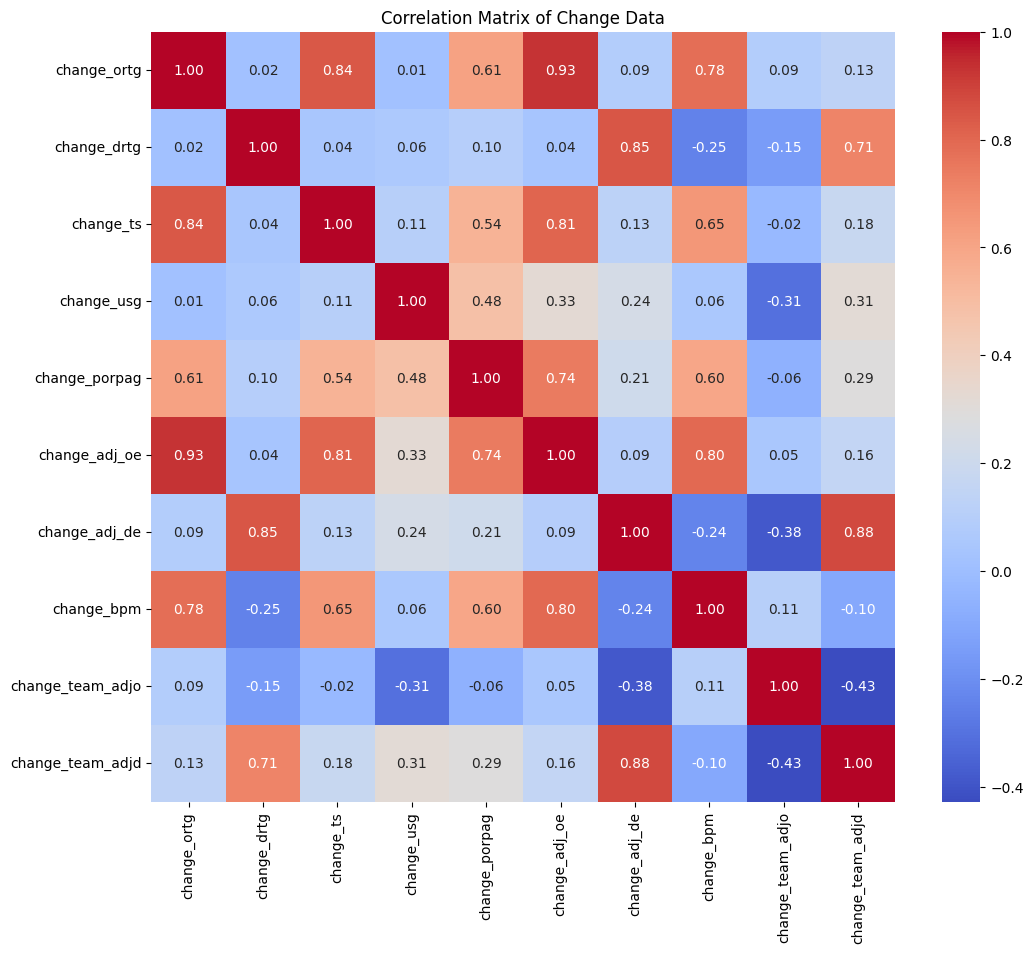

In [ ]:
change_columns = [
    'change_ortg', 'change_drtg', 'change_ts', 'change_usg',
    'change_porpag', 'change_adj_oe', 'change_adj_de', 'change_bpm',
    'change_team_adjo', 'change_team_adjd'
]

correlation_matrix = df_transfers[change_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Change Data')
plt.show()


In [ ]:
# Define a function to categorize barthag movement
def categorize_barthag_movement(change_barthag):
    if pd.isna(change_barthag):
        return None
    elif change_barthag > .1:
        return "up"
    elif change_barthag < -.1:
        return "down"
    else:
        return "lateral"

# Apply the function to create the new categorical column
df_transfers["barthag_movement"] = df_transfers["change_barthag"].apply(categorize_barthag_movement)

# Display the value counts for the new column to verify
print("Barthag Movement Category Counts:")
print(df_transfers["barthag_movement"].value_counts(dropna=False))


Barthag Movement Category Counts:
barthag_movement
None       1302
down        946
up          887
lateral     707
Name: count, dtype: int64


Text(0.5, 1.0, 'BPM Change by Transfer Direction')

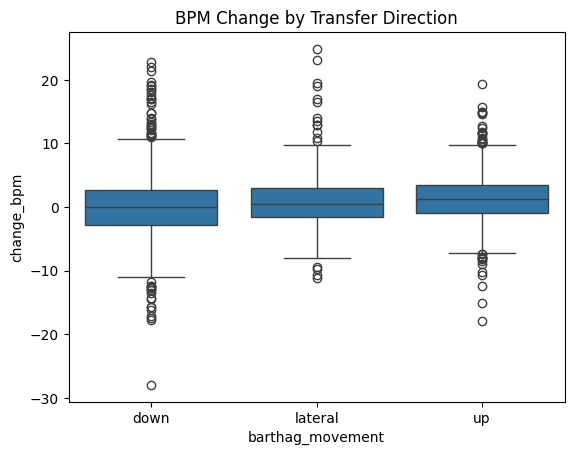

In [ ]:
sns.boxplot(x='barthag_movement', y='change_bpm', data=df_transfers)
plt.title('BPM Change by Transfer Direction')

Text(0.5, 1.0, 'True shooting Change by Transfer Direction')

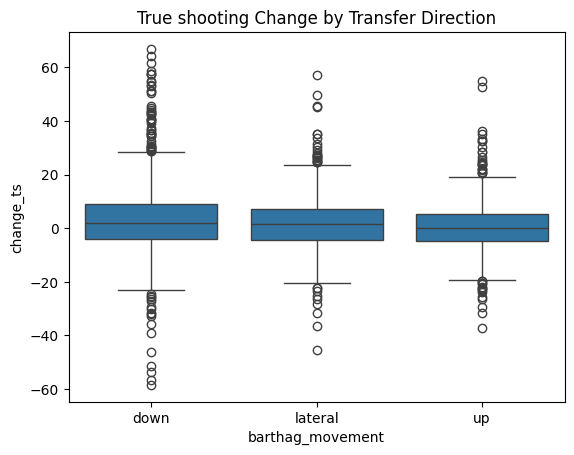

In [ ]:
sns.boxplot(x='barthag_movement', y='change_ts', data=df_transfers)
plt.title('True shooting Change by Transfer Direction')

Text(0.5, 1.0, 'Defensive Rating Change by Transfer Direction')

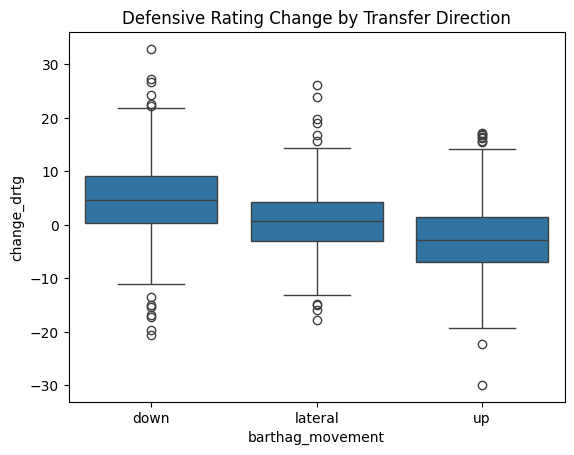

In [ ]:
sns.boxplot(x='barthag_movement', y='change_drtg', data=df_transfers)
plt.title('Defensive Rating Change by Transfer Direction')

Text(0.5, 1.0, 'Offensive Rating Change by Transfer Direction')

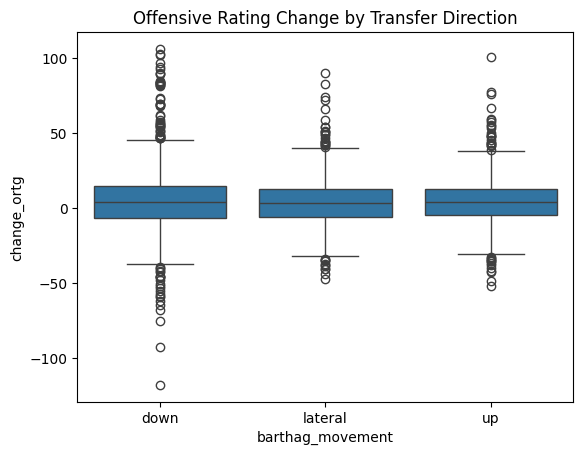

In [ ]:
sns.boxplot(x='barthag_movement', y='change_ortg', data=df_transfers)
plt.title('Offensive Rating Change by Transfer Direction')

Text(0.5, 1.0, 'Usuage rate Change by Transfer Direction')

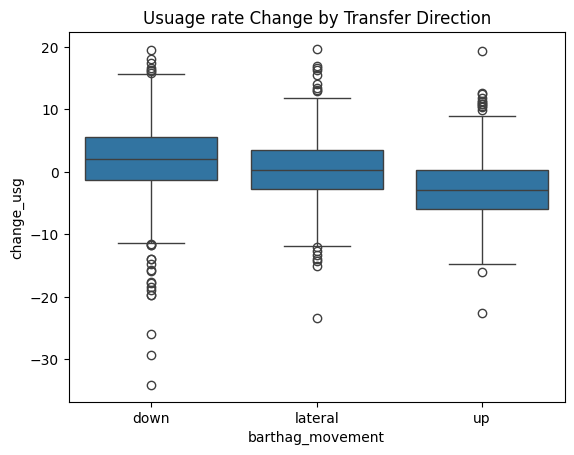

In [ ]:
sns.boxplot(x='barthag_movement', y='change_usg', data=df_transfers)
plt.title('Usuage rate Change by Transfer Direction')

Text(0.5, 1.0, 'Usuage rate Change by Transfer Direction')

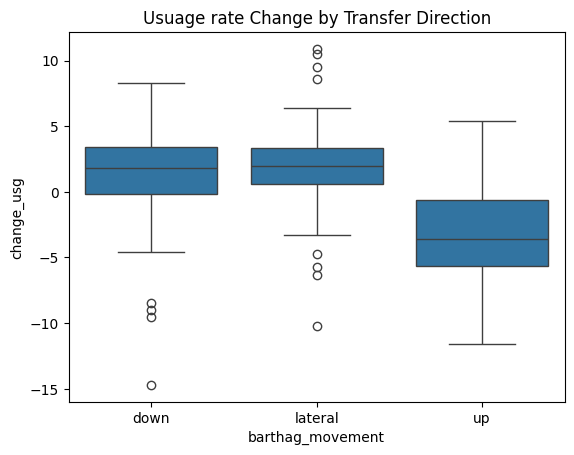

In [ ]:
sns.boxplot(x='barthag_movement', y='change_usg', data= a10_transfers)
plt.title('Usuage rate Change by Transfer Direction')

Text(0.5, 1.0, 'box plus minus Change by Transfer Direction')

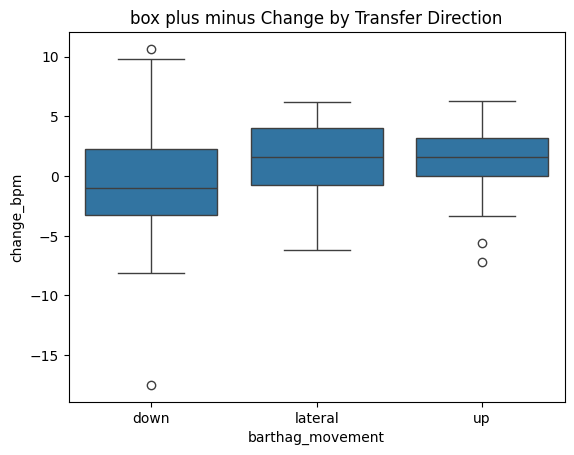

In [ ]:
sns.boxplot(x='barthag_movement', y='change_bpm', data=a10_transfers)
plt.title('box plus minus Change by Transfer Direction in the A10')

Text(0.5, 1.0, 'Defensive rating Change by Transfer Direction')

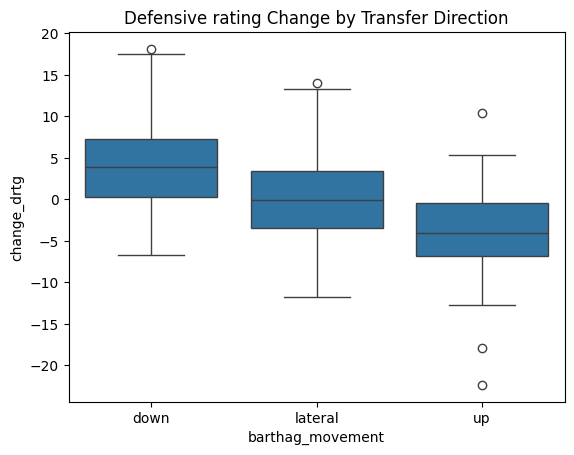

In [ ]:
sns.boxplot(x='barthag_movement', y='change_drtg', data=a10_transfers)
plt.title('Defensive rating Change by Transfer Direction in the A10')

Text(0.5, 1.0, 'Offensive rating Change by Transfer Direction')

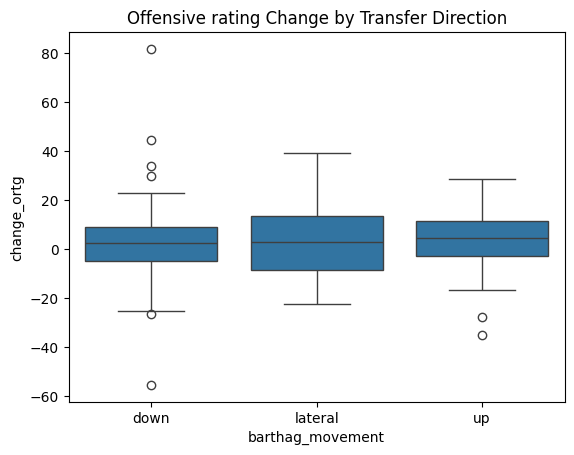

In [ ]:
sns.boxplot(x='barthag_movement', y='change_ortg', data=a10_transfers)
plt.title('Offensive rating Change by Transfer Direction in the A10')

Text(0.5, 1.0, 'Usage rate Change by Transfer Direction in the A10')

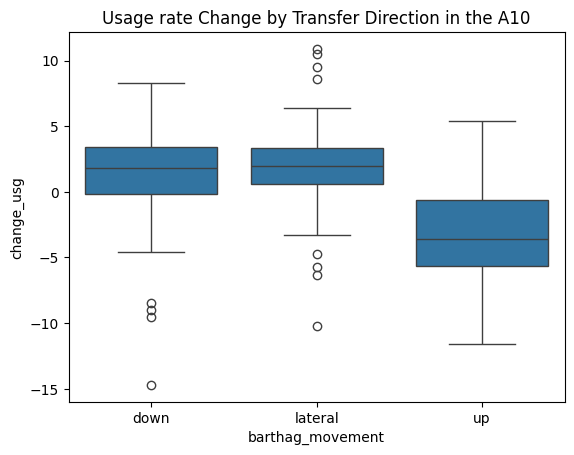

In [ ]:
sns.boxplot(x='barthag_movement', y='change_usg', data=a10_transfers)
plt.title('Usage rate Change by Transfer Direction in the A10')

<Axes: xlabel='change_bpm', ylabel='Density'>

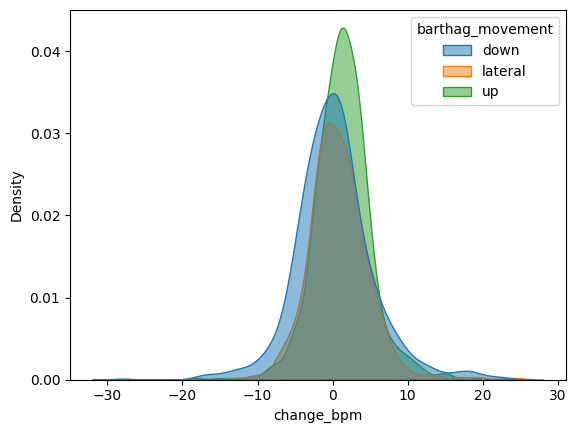

In [ ]:
sns.kdeplot(data=df_transfers, x='change_bpm', hue='barthag_movement', fill=True, alpha=0.5)

<Axes: xlabel='change_usg', ylabel='Density'>

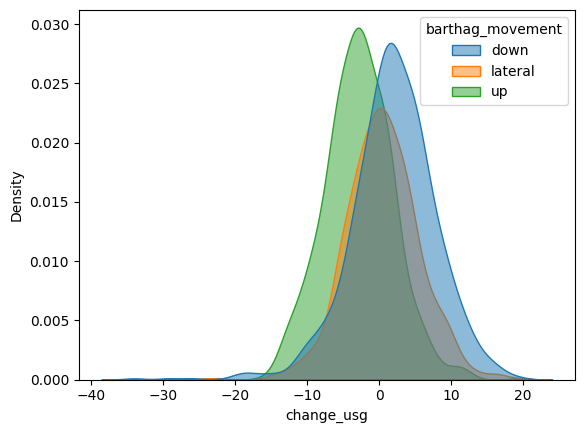

In [ ]:
sns.kdeplot(data=df_transfers, x='change_usg', hue='barthag_movement', fill=True, alpha=0.5)

<Axes: xlabel='change_drtg', ylabel='Density'>

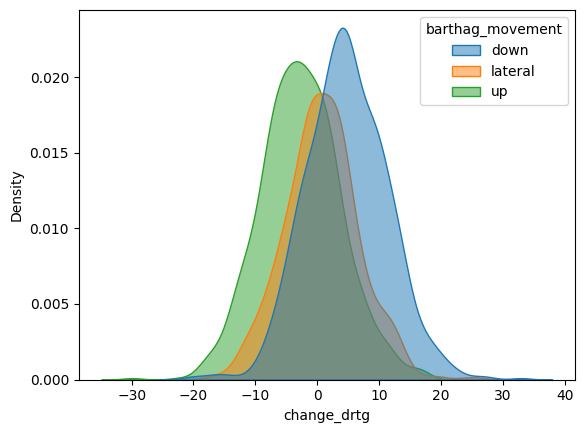

In [ ]:
sns.kdeplot(data=df_transfers, x='change_drtg', hue='barthag_movement', fill=True, alpha=0.5)

In [ ]:
from scipy import stats

up = df_transfers[df_transfers['barthag_movement']=='up']['change_bpm']
down = df_transfers[df_transfers['barthag_movement']=='down']['change_bpm']
lateral = df_transfers[df_transfers['barthag_movement']=='lateral']['change_bpm']

f_stat, p_value = stats.f_oneway(up, down, lateral)
print(f"F-statistic: {f_stat}, p-value: {p_value}")


F-statistic: 14.553223718368063, p-value: 5.19513097326603e-07


In [ ]:
up = df_transfers[df_transfers['barthag_movement']=='up']['change_usg']
down = df_transfers[df_transfers['barthag_movement']=='down']['change_usg']
lateral = df_transfers[df_transfers['barthag_movement']=='lateral']['change_usg']

f_stat, p_value = stats.f_oneway(up, down, lateral)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 187.4164646032549, p-value: 1.217214082398072e-76


In [ ]:
up = df_transfers[df_transfers['barthag_movement']=='up']['change_drtg']
down = df_transfers[df_transfers['barthag_movement']=='down']['change_drtg']
lateral = df_transfers[df_transfers['barthag_movement']=='lateral']['change_drtg']

f_stat, p_value = stats.f_oneway(up, down, lateral)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 309.9425968086064, p-value: 3.7216869412074374e-121


<function matplotlib.pyplot.show(close=None, block=None)>

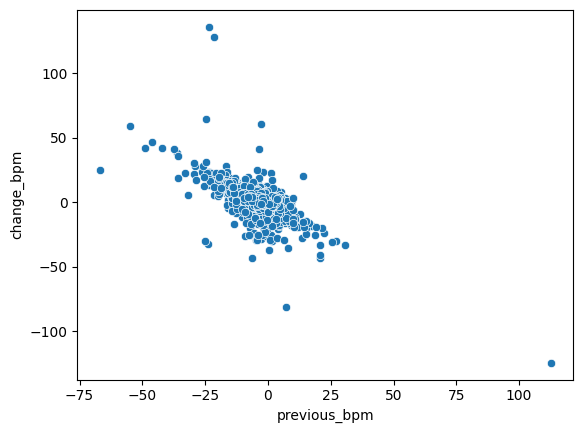

In [ ]:
sns.scatterplot(data = df_transfers, x = "previous_bpm", y = "change_bpm")
plt.show

Text(0.5, 1.0, 'Previous Conferences of Transfers into the A-10')

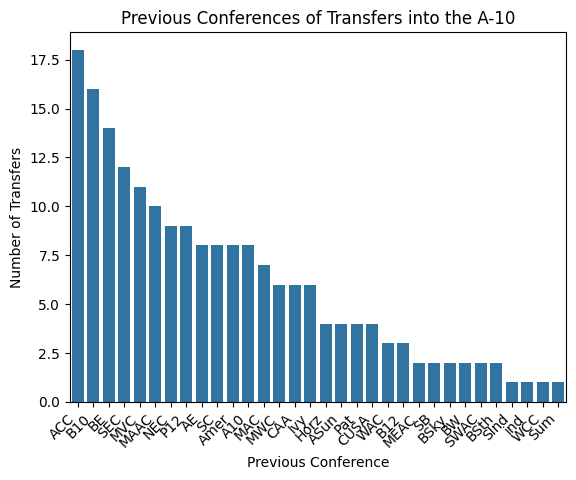

In [ ]:
sns.countplot(x="previous_conference", stat="count",
              order = a10_transfers['previous_conference'].value_counts().index, data= a10_transfers)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Previous Conference")
plt.ylabel("Number of Transfers")
plt.title("Previous Conferences of Transfers into the A-10")


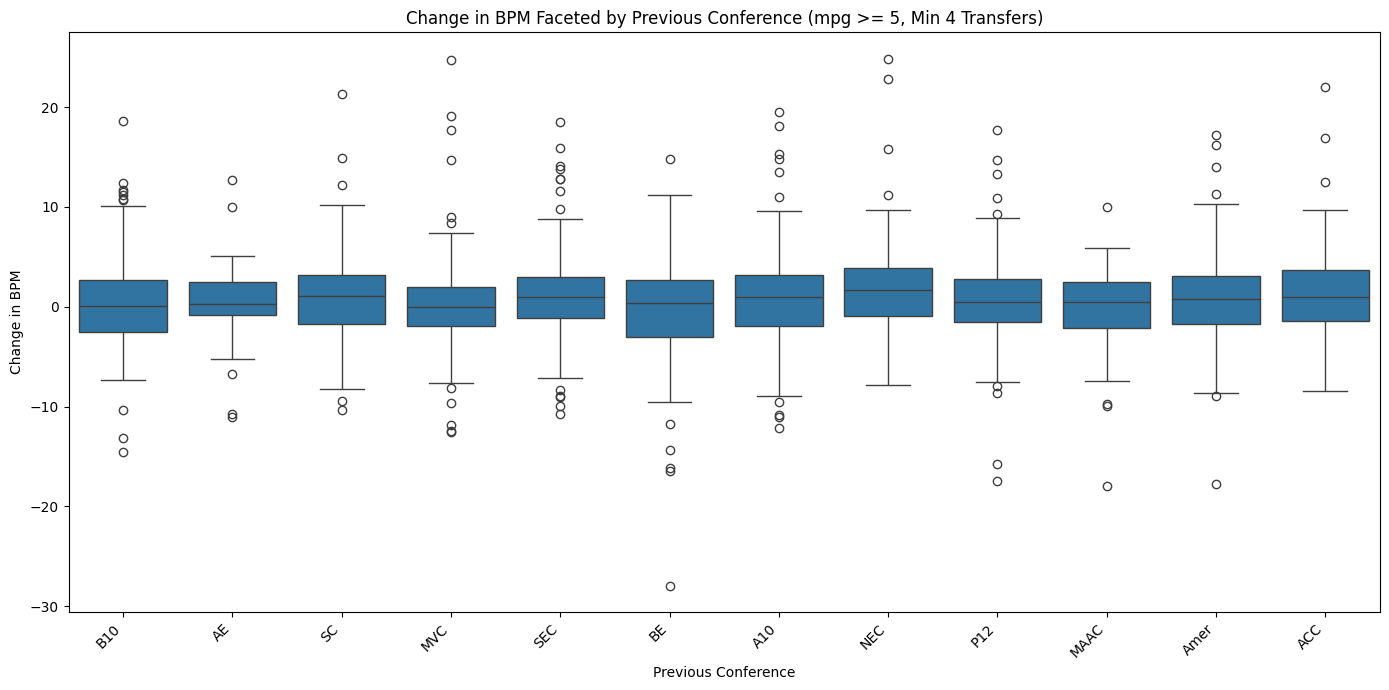

In [ ]:
conference_counts = df_transfers['previous_conference'].value_counts()
conferences_to_include = ['ACC','B10','BE','SEC','MVC','MAAC','NEC','P12','AE','SC','Amer','A10']

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_transfers[(df_transfers['mpg'] >= 5) & (df_transfers['previous_conference'].isin(conferences_to_include))],
    x="previous_conference",
    y="change_bpm"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Previous Conference")
plt.ylabel("Change in BPM")
plt.title("Change in BPM Faceted by Previous Conference (mpg >= 5, Min 4 Transfers)")
plt.tight_layout()
plt.show()

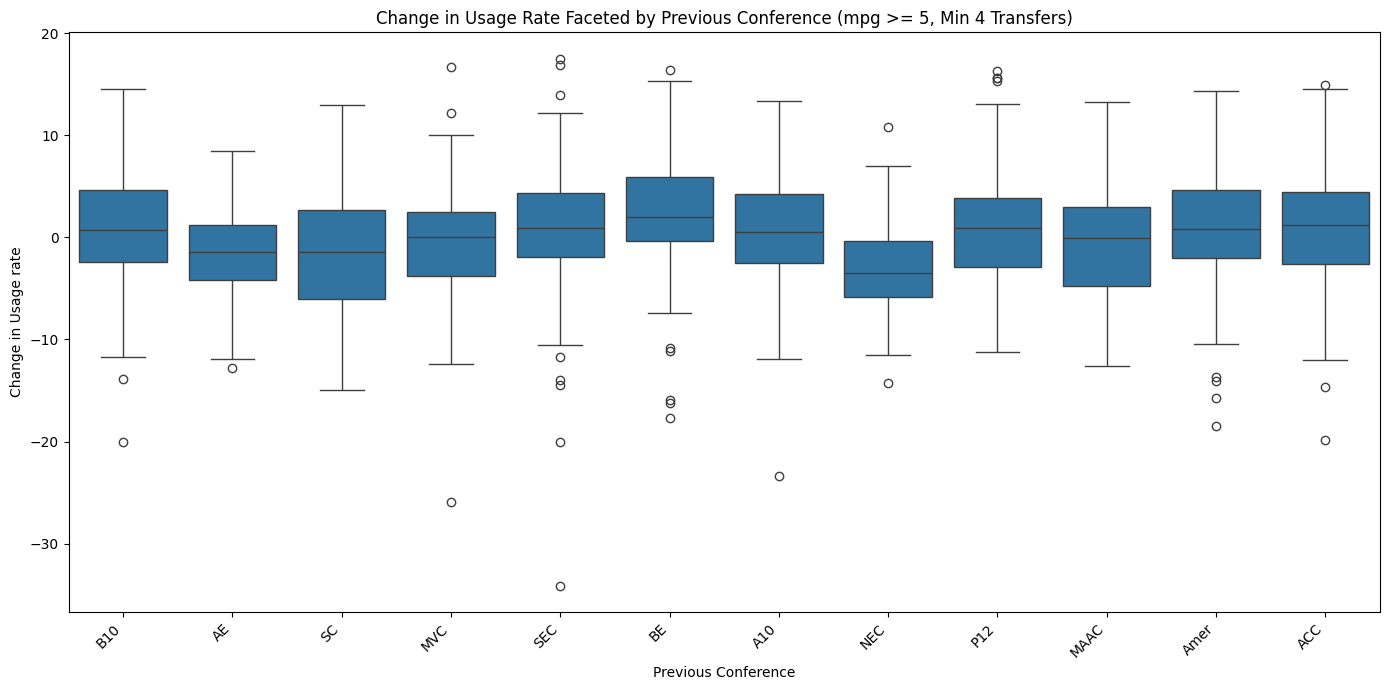

In [ ]:
conference_counts = df_transfers['previous_conference'].value_counts()
conferences_to_include = ['ACC','B10','BE','SEC','MVC','MAAC','NEC','P12','AE','SC','Amer','A10']

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_transfers[(df_transfers['mpg'] >= 5) & (df_transfers['previous_conference'].isin(conferences_to_include))],
    x="previous_conference",
    y="change_usg"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Previous Conference")
plt.ylabel("Change in Usage rate")
plt.title("Change in Usage Rate Faceted by Previous Conference (mpg >= 5, Min 4 Transfers)")
plt.tight_layout()
plt.show()

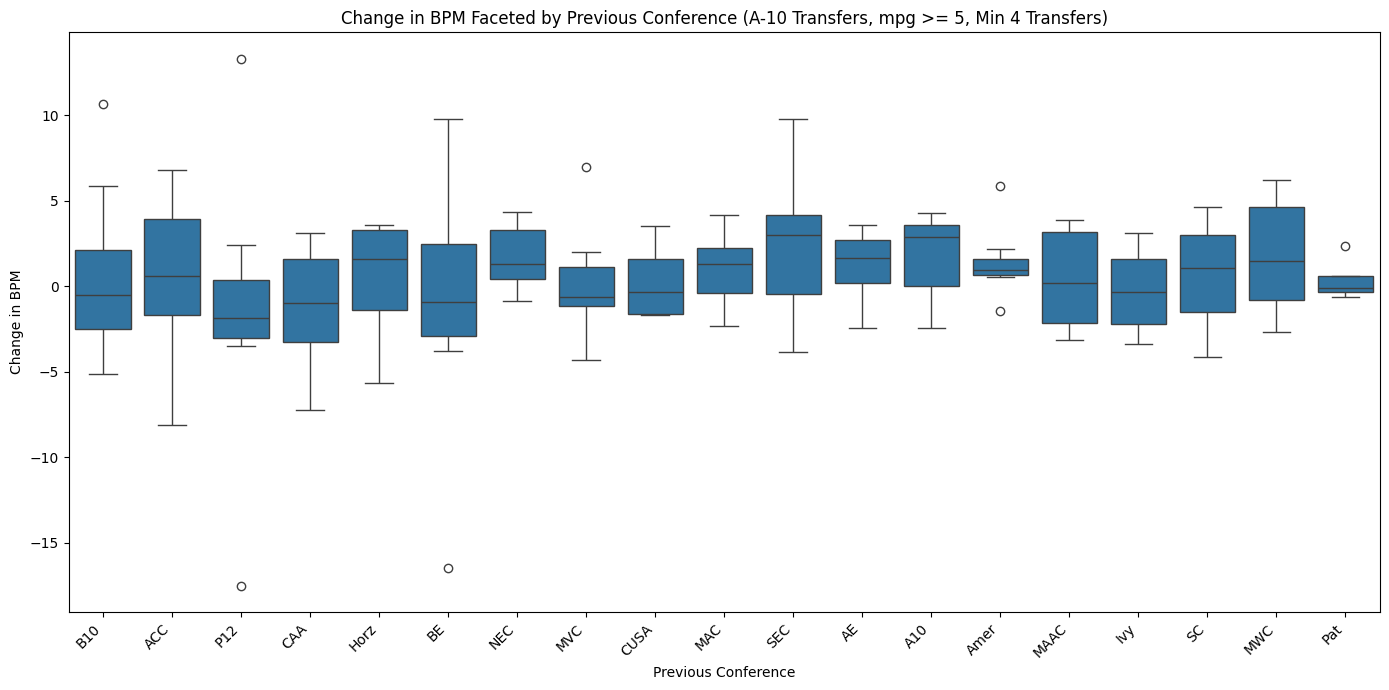

In [ ]:
conference_counts = a10_transfers['previous_conference'].value_counts()
conferences_to_include = conference_counts[conference_counts >= 4].index.tolist()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=a10_transfers[(a10_transfers['mpg'] >= 5) & (a10_transfers['previous_conference'].isin(conferences_to_include))],
    x="previous_conference",
    y="change_bpm"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Previous Conference")
plt.ylabel("Change in BPM")
plt.title("Change in BPM Faceted by Previous Conference (A-10 Transfers, mpg >= 5, Min 4 Transfers)")
plt.tight_layout()
plt.show()

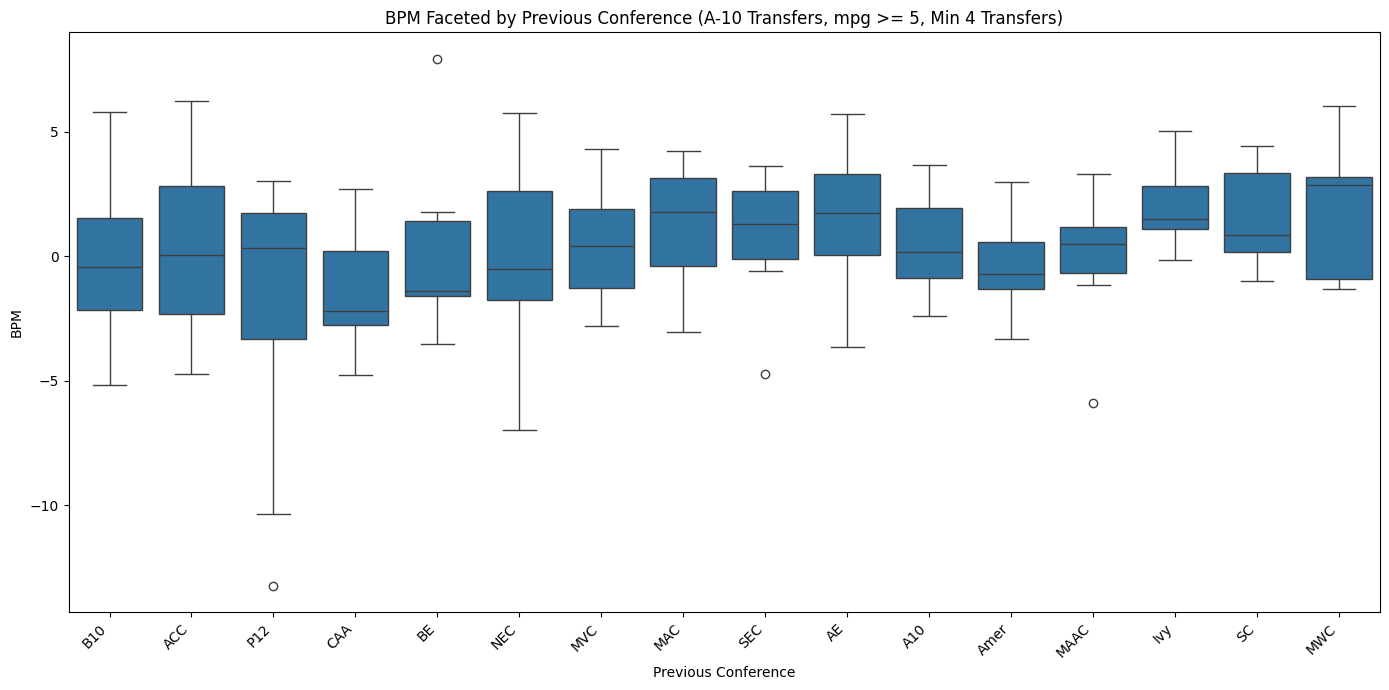

In [ ]:
conference_counts = a10_transfers['previous_conference'].value_counts()
conferences_to_include = conference_counts[conference_counts >= 5].index.tolist()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=a10_transfers[(a10_transfers['mpg'] >= 5) & (a10_transfers['previous_conference'].isin(conferences_to_include))],
    x="previous_conference",
    y="bpm"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Previous Conference")
plt.ylabel("BPM")
plt.title("BPM Faceted by Previous Conference (A-10 Transfers, mpg >= 5, Min 4 Transfers)")
plt.tight_layout()
plt.show()

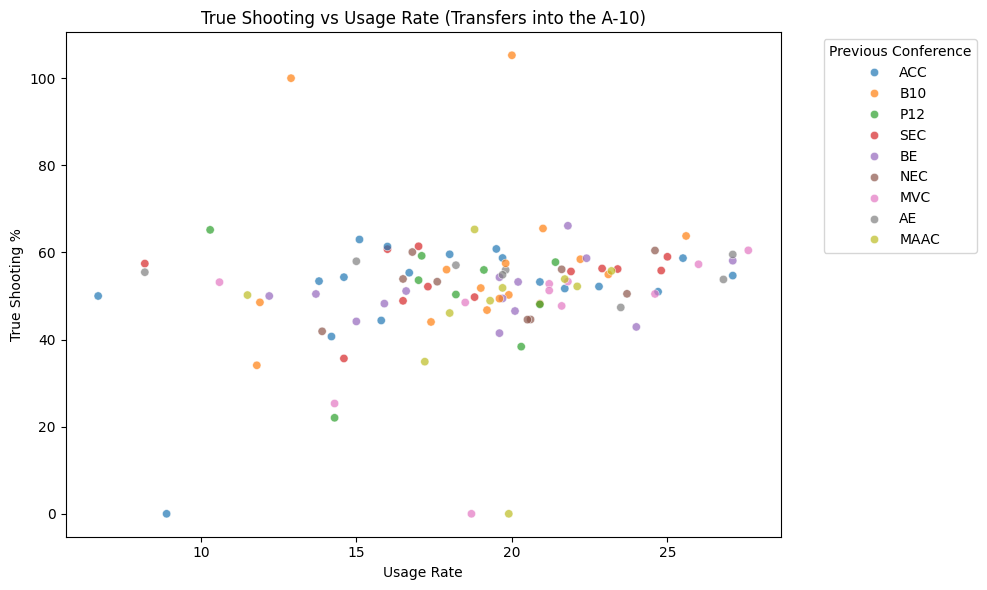

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data = a10_transfers[(a10_transfers['previous_conference']=="ACC") | (a10_transfers['previous_conference']=="B10") |
                         (a10_transfers['previous_conference']=="BE") | (a10_transfers['previous_conference']=="SEC") |
                         (a10_transfers['previous_conference']=="MVC") | (a10_transfers['previous_conference']=="MAAC") |
                         (a10_transfers['previous_conference']=="NEC") | (a10_transfers['previous_conference']=="P12") |
                         (a10_transfers['previous_conference']=="AE")],
    x = "usg",
    y = "ts",
    hue = "previous_conference",
    alpha = 0.7
)

plt.xlabel("Usage Rate")
plt.ylabel("True Shooting %")
plt.title("True Shooting vs Usage Rate (Transfers into the A-10)")
plt.legend(title="Previous Conference", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


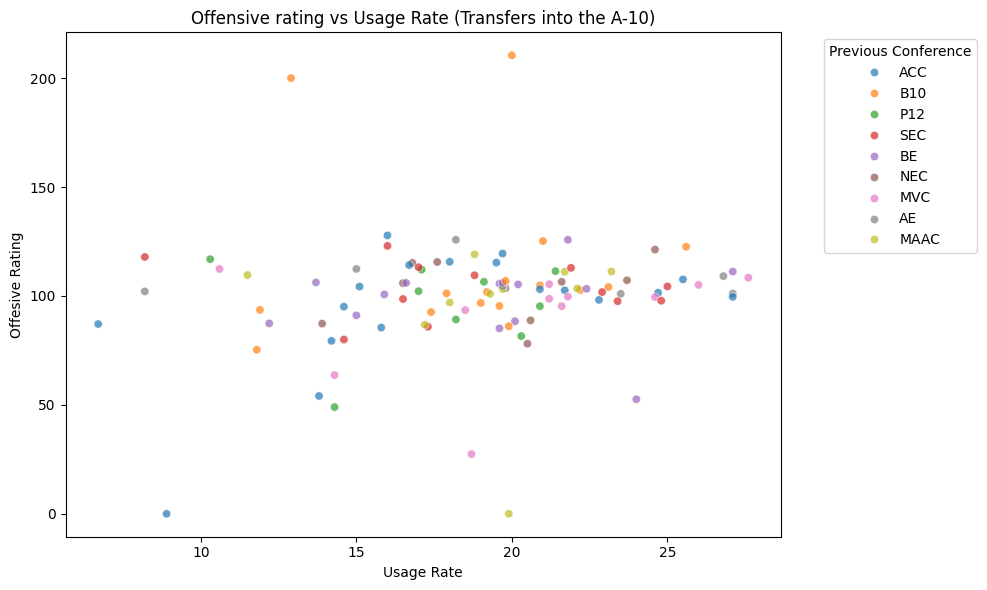

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data = a10_transfers[(a10_transfers['previous_conference']=="ACC") | (a10_transfers['previous_conference']=="B10") |
                         (a10_transfers['previous_conference']=="BE") | (a10_transfers['previous_conference']=="SEC") |
                         (a10_transfers['previous_conference']=="MVC") | (a10_transfers['previous_conference']=="MAAC") |
                         (a10_transfers['previous_conference']=="NEC") | (a10_transfers['previous_conference']=="P12") |
                         (a10_transfers['previous_conference']=="AE") & (a10_transfers['mpg']>=5)],
    x = "usg",
    y = "ortg",
    hue = "previous_conference",
    alpha = 0.7
)

plt.xlabel("Usage Rate")
plt.ylabel("Offesive Rating")
plt.title("Offensive rating vs Usage Rate (Transfers into the A-10)")
plt.legend(title="Previous Conference", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()